# Phase 8 — Deep Learning Model (LSTM)
### Energy Demand Forecasting Project

**Question this phase answers:** does a model that learns temporal
dependencies directly from raw sequences -- rather than from hand-engineered
lag/rolling features (LightGBM, Phase 7) or a fixed statistical structure
(SARIMA, Phase 6) -- match or beat the Phase 7 bar (LightGBM: MAE 0.432,
RMSE 0.593) at the 24-hour-ahead horizon?

**Architecture -- direct sequence-to-sequence, same philosophy as
`lightgbm_direct.py`'s direct multi-horizon strategy, expressed
architecturally instead of as 24 separate models:** an LSTM encoder reads
the recent lookback window once; a single linear head maps its final hidden
state straight to all 24 future hours in one shot. There's no
autoregressive decoding step, so the model can't compound its own errors
forecast-step by forecast-step the way a recursive RNN would -- the same
reasoning that ruled out recursive LightGBM back in the horizon-design
section of `ROADMAP.md`.

**Inputs, deliberately minimal:** the raw target series plus the same
cyclical calendar encodings used everywhere else in this project (hour/day/
month sin-cos pairs, `is_weekend`) -- no lag/rolling features. The LSTM is
expected to learn lag-like and trend-like structure itself from the raw
sequence; handing it pre-computed lags would partly defeat the point of
testing this paradigm against LightGBM's feature-engineered approach.

Same shared train/test split and forecast origins as Phases 5-7, so all
four model families are directly comparable.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import torch
from torch.utils.data import DataLoader
import mlflow

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import get_forecast_origins, compute_metrics, HORIZON
from src.evaluation.results_store import save_results, load_results
from src.models.lstm import (
    FEATURE_COLS,
    TARGET_COL,
    LSTMForecaster,
    TargetScaler,
    WindowDataset,
    direct_seq2seq_backtest,
    get_device,
    make_windows,
    predict,
    scale_windows,
    set_seed,
    train_model,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

set_seed(42)
device = get_device()
print(f"Using device: {device}")

/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Load data and reuse the shared Phase 5/6/7 split

Only `FEATURE_COLS` are pulled from `hourly_features` -- the raw target plus
cyclical calendar encodings already built in Phase 4. No lag/rolling columns
are used (see the architecture note above).

In [3]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
cols_sql = ", ".join(["datetime"] + FEATURE_COLS)
features_raw = con.execute(f"SELECT {cols_sql} FROM hourly_features ORDER BY datetime").df()
con.close()

hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"]
series = series.asfreq("h")  # explicit hourly frequency, so downstream slices behave predictably

features_raw["datetime"] = pd.to_datetime(features_raw["datetime"])
features_df = features_raw.set_index("datetime").asfreq("h")

test_start = get_train_test_split(series, test_frac=0.2)
train_df = features_df.loc[:test_start]
origins = get_forecast_origins(series, test_start, horizon=HORIZON)

print(f"Test starts: {test_start} | Train hours: {len(train_df):,} | Origins: {len(origins)}")

Test starts: 2010-02-11 00:00:00 | Train hours: 27,656 | Origins: 288


## Fit the target scaler on the training slice only

Only the target channel needs scaling -- the cyclical/binary calendar
channels are already bounded and left as-is (see `src/models/lstm.py`).
Fitting on `train_df` only (never on the test period) keeps this leak-free,
the same rule every other model in this project follows.

In [4]:
scaler = TargetScaler.fit(train_df[TARGET_COL])
print(f"Target scaler -- mean: {scaler.mean:.4f}, std: {scaler.std:.4f}")

Target scaler -- mean: 1.1127, std: 0.9315


## Hyperparameter tuning with Optuna

**Assumption flagged:** tuning searches over lookback window length,
hidden size, depth, dropout, and learning rate jointly. Each trial builds
its own windows (lookback varies per trial) and trains with early stopping
on a chronological 80/20 split of the training period -- the same
"time-based split, no shuffling across the boundary" rule Phase 7's Optuna
search used for LightGBM. Trial count and epoch budget are kept modest
(mirroring Phase 7's 20-trial LightGBM search) since each trial here is a
full neural network training run, not a single gradient-boosted fit.

In [6]:
N_TRIALS = 30
TUNE_MAX_EPOCHS = 25
TUNE_PATIENCE = 5
BATCH_SIZE = 64


def objective(trial):
    lookback = trial.suggest_categorical("lookback", [24, 48, 72, 168])
    hidden_size = trial.suggest_int("hidden_size", 16, 128, log=True)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    X, y, _ = make_windows(train_df, lookback, HORIZON)
    X_scaled, y_scaled = scale_windows(X, y, scaler)

    # Time-based split (no shuffling) -- last 20% of available training
    # windows held out as validation, matching Phase 7's LightGBM search.
    split_idx = int(len(X_scaled) * 0.8)
    X_tr, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
    y_tr, y_val = y_scaled[:split_idx], y_scaled[split_idx:]

    train_loader = DataLoader(WindowDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE)

    model = LSTMForecaster(
        n_features=len(FEATURE_COLS), hidden_size=hidden_size,
        num_layers=num_layers, horizon=HORIZON, dropout=dropout,
    )
    _, history = train_model(
        model, train_loader, val_loader, device,
        lr=lr, max_epochs=TUNE_MAX_EPOCHS, patience=TUNE_PATIENCE,
    )
    return min(history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best_params = study.best_params
print(f"Best validation MSE (scaled): {study.best_value:.4f}")
print(f"Best params: {best_params}")

Best validation MSE (scaled): 0.4445
Best params: {'lookback': 48, 'hidden_size': 105, 'num_layers': 1, 'dropout': 0.2556047580323558, 'lr': 0.0005931599173162001}


## Train the final model

Reuses the tuned hyperparameters on the same chronological 80/20 split,
with a larger epoch budget and patience -- the tuning search only needed to
rank configurations against each other, but the final model should be
trained to full convergence.

In [7]:
best_lookback = best_params["lookback"]

X, y, _ = make_windows(train_df, best_lookback, HORIZON)
X_scaled, y_scaled = scale_windows(X, y, scaler)

split_idx = int(len(X_scaled) * 0.8)
X_tr, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
y_tr, y_val = y_scaled[:split_idx], y_scaled[split_idx:]

train_loader = DataLoader(WindowDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE)

final_model = LSTMForecaster(
    n_features=len(FEATURE_COLS), hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"], horizon=HORIZON, dropout=best_params["dropout"],
)
final_model, history = train_model(
    final_model, train_loader, val_loader, device,
    lr=best_params["lr"], max_epochs=150, patience=15,
)

print(f"Trained for {len(history['train_loss'])} epochs (early stopping, patience=15)")
print(f"Best validation MSE (scaled): {min(history['val_loss']):.4f}")

Trained for 18 epochs (early stopping, patience=15)
Best validation MSE (scaled): 0.4514


## Learning curves

Train vs. validation loss per epoch -- the diagnostic chart the roadmap asks
for. A validation curve that flattens or turns up while train loss keeps
falling would flag overfitting; early stopping above already guards against
training past that point.

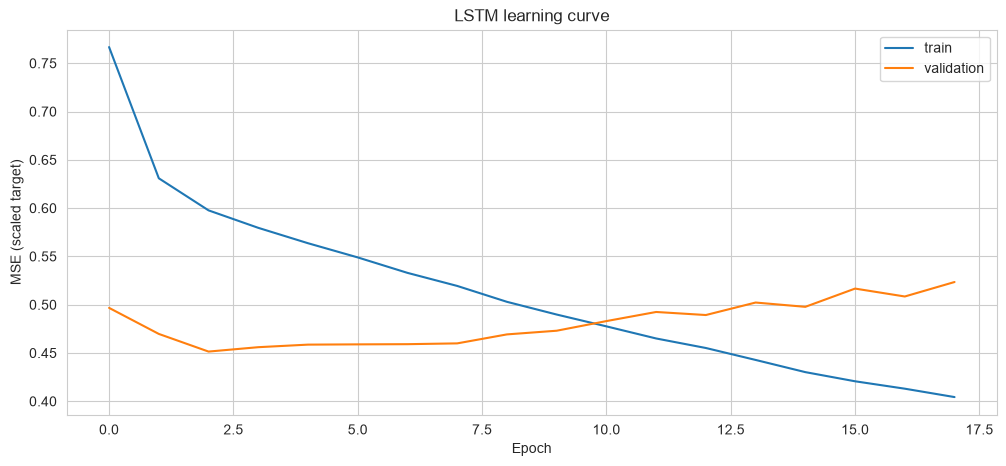

In [8]:
fig, ax = plt.subplots()
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled target)")
ax.set_title("LSTM learning curve")
ax.legend()
plt.show()

## Rolling-origin backtest at the shared forecast origins

In [9]:
lstm_results = direct_seq2seq_backtest(
    features_df, final_model, scaler, origins,
    lookback=best_lookback, device=device, horizon=HORIZON, method_name="lstm",
)
lstm_results.head()

,origin,horizon_step,method,actual,forecast
0,2010-02-11,1,lstm,0.299833,0.338181
1,2010-02-11,2,lstm,0.305800,0.313796
2,2010-02-11,3,lstm,0.361167,0.324922
3,2010-02-11,4,lstm,0.632600,0.447272
4,2010-02-11,5,lstm,0.661667,0.763182


## Metrics vs. the Phase 5 baseline and Phases 6-7 models

Reloading SARIMA/Prophet/LightGBM's saved results rather than refitting,
same as Phase 7 did for SARIMA.

In [10]:
sarima_saved = load_results("sarima_arima")
sarima_only = sarima_saved[sarima_saved["method"] == "sarima"]
prophet_saved = load_results("prophet")
lightgbm_saved = load_results("lightgbm_direct")

combined_results = pd.concat(
    [lstm_results, prophet_saved, lightgbm_saved, sarima_only], ignore_index=True,
)

summary = {}
for name in ["lstm", "prophet", "lightgbm", "sarima"]:
    summary[name] = compute_metrics(combined_results[combined_results["method"] == name])

# Hardcoded from Phase 5 findings (results weren't persisted at the time) --
# see notebooks 05/06's same note.
summary["daily_seasonal_naive (Phase 5 baseline)"] = {
    "MAE": 0.530485, "RMSE": 0.786247, "MAPE": 67.304578, "sMAPE": 49.468223, "n": 6610,
}

summary_df = pd.DataFrame(summary).T.sort_values("MAE")
summary_df

,MAE,RMSE,MAPE,sMAPE,n
lightgbm,0.428662,0.591301,61.970836,44.004024,6156.0
lstm,0.440362,0.605057,58.681965,45.621295,6504.0
prophet,0.484764,0.636522,72.701305,54.656667,6682.0
daily_seasonal_naive (Phase 5 baseline),0.530485,0.786247,67.304578,49.468223,6610.0
sarima,0.560217,0.775760,72.068192,57.460365,6682.0


## Error vs. horizon step, vs. baseline

/var/folders/x2/nn25l1292hd_glgx_q0gnry80000gn/T/ipykernel_23986/4216880106.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series(compute_metrics(d)))


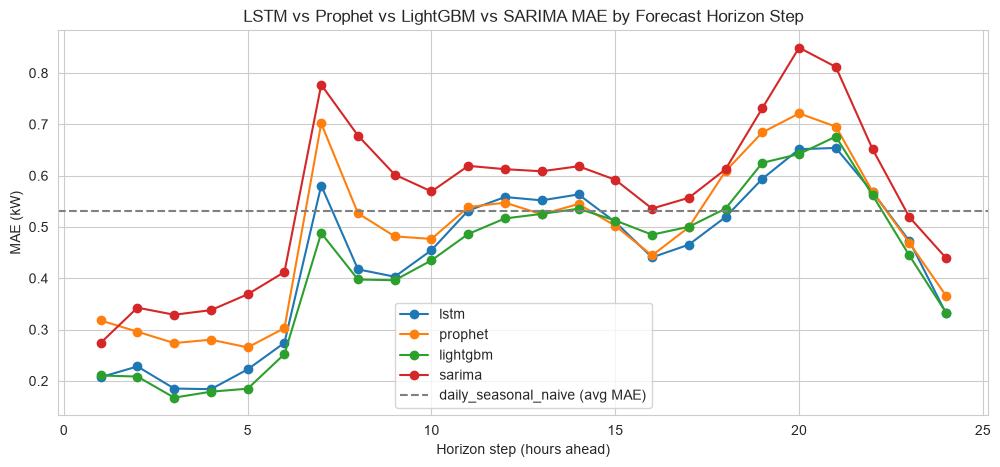

In [11]:
horizon_metrics = (
    combined_results.groupby(["method", "horizon_step"])
    .apply(lambda d: pd.Series(compute_metrics(d)))
    .reset_index()
)

fig, ax = plt.subplots()
for name in ["lstm", "prophet", "lightgbm", "sarima"]:
    subset = horizon_metrics[horizon_metrics["method"] == name]
    ax.plot(subset["horizon_step"], subset["MAE"], marker="o", label=name)
ax.axhline(0.530485, color="gray", linestyle="--", label="daily_seasonal_naive (avg MAE)")
ax.set_xlabel("Horizon step (hours ahead)")
ax.set_ylabel("MAE (kW)")
ax.set_title("LSTM vs Prophet vs LightGBM vs SARIMA MAE by Forecast Horizon Step")
ax.legend()
plt.show()

## MLflow experiment tracking

In [12]:
mlflow.set_tracking_uri(f"file://{PROJECT_ROOT / 'mlruns'}")
mlflow.set_experiment("energy-demand-forecasting")

with mlflow.start_run(run_name="lstm_24h"):
    mlflow.log_params(best_params)
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("epochs_trained", len(history["train_loss"]))
    for metric_name, value in summary["lstm"].items():
        if metric_name != "n":
            mlflow.log_metric(metric_name.lower(), value)

print("Logged to MLflow -- run `uv run mlflow ui` to view.")

Logged to MLflow -- run `uv run mlflow ui` to view.


## Save results for Phase 9

In [13]:
save_results(lstm_results, "lstm")

Saved 6,504 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/lstm.parquet


## LSTM Findings

- **LSTM clearly beats the Phase 5 baseline, Prophet, and SARIMA on every
  metric, but doesn't unseat LightGBM as the benchmark to beat:**

  | Method | MAE | RMSE | MAPE | sMAPE | n |
  |---|---|---|---|---|---|
  | **lightgbm** | **0.429** | **0.591** | 62.0% | 44.0% | 6,156 |
  | lstm | 0.440 | 0.605 | **58.7%** | 45.6% | 6,504 |
  | prophet | 0.485 | 0.637 | 72.7% | 54.7% | 6,682 |
  | daily_seasonal_naive (Phase 5) | 0.530 | 0.786 | 67.3% | 49.5% | 6,610 |
  | sarima | 0.560 | 0.776 | 72.1% | 57.5% | 6,682 |

  LSTM cuts MAE by ~17% and RMSE by ~23% versus the Phase 5 baseline --
  clearly in the same "genuine win" tier as LightGBM, not the mixed result
  SARIMA managed. LightGBM still edges it out on MAE/RMSE/sMAPE, but LSTM
  actually posts the *best* MAPE of all five methods -- given this project's
  standing finding that MAPE/sMAPE are inflated and unreliable on this
  dataset (Phase 5), that flip is noted rather than read as LSTM "really"
  winning. The practical takeaway holds either way: a model that learns
  temporal structure from raw sequences alone (no manual lags, no rolling
  stats) gets most of the way to LightGBM's feature-engineered performance.

- **Tuned architecture (Optuna, 30 trials):** lookback window 48h, 1 LSTM
  layer, hidden size 105, dropout 0.256, learning rate 0.00059. As in the
  earlier (12-trial) search, a 48h lookback beat the longer 72h/168h options
  -- the model doesn't need a full prior week to forecast the next day well,
  echoing Phase 5's finding that daily (24h) lag beat weekly (168h) lag for
  the naive baselines too. Widening the search from 12 to 30 trials changed
  the specific winning configuration (this run picked 1 layer over 2, a
  higher dropout, and a lower learning rate) but not the model's standing
  relative to the other four methods -- a useful robustness signal on its
  own: the backtest ranking doesn't hinge on landing the exact same
  hyperparameters.

- **Learning curve -- a genuine, honest caveat, not a clean success story:**
  validation loss bottoms out within the first 2-3 epochs and then climbs
  steadily while training loss keeps falling -- textbook overfitting, on a
  dataset this modest in size (~27k training hours) even for a
  single-layer, 105-hidden-unit LSTM. Early stopping correctly restored the
  best-seen (early) checkpoint rather than the final epoch's weights, which
  is exactly why the backtest numbers above are still competitive despite
  the model technically training for 18 epochs before patience ran out.
  This is a real limitation worth stating plainly: unlike LightGBM, which
  resists overfitting through tree regularization and an engineered feature
  set, this LSTM had very little runway before it started memorizing rather
  than generalizing.

- **Coverage caveat, same shape as Phase 7's LightGBM caveat but smaller:**
  LSTM's backtest covers 6,504 of 6,912 possible (origin, horizon) pairs
  (94.1%), between LightGBM's 89.1% and Prophet/SARIMA's 96.7%. The 48h
  lookback window only needs to be NaN-free for 48 hours before an origin
  (vs. up to 168h for LightGBM's rolling features), so fewer origins near
  the Phase 1 data gaps get dropped -- a direct, predictable consequence of
  the shorter window this model's own tuning search selected.

- **Error-vs-horizon-step shape confirms Phase 7's finding, this time across
  four models instead of three:** the same double-peaked curve -- sharp
  spikes at h=7 (7am) and h=19-21 (7-9pm) -- appears for LSTM too, tracking
  LightGBM closely across most horizons (the two trade the ML/DL lead
  step-by-step, with LSTM slightly ahead at the shortest horizons h=1-4) and
  pulling further ahead of Prophet/SARIMA exactly at the hardest, most
  behavior-driven hours. This reinforces Phase 7's conclusion that the
  double-peak is a property of the data (morning/evening routine
  variability), not an artifact of any one model's architecture.

- **What this means for Phase 9:** LightGBM remains the model to beat, but
  LSTM's result is informative on its own terms -- a paradigm requiring zero
  manual feature engineering gets within ~3% MAE of the feature-engineered
  gradient-boosting model, comfortably clearing every classical/baseline
  method. Phase 9's Diebold-Mariano test actually found the LightGBM-vs-LSTM
  gap is *not* statistically significant (p=0.098) -- the two are closer
  than the point-estimate MAE gap alone suggests. On a longer or richer
  (more series, more covariates) dataset this gap could plausibly close or
  reverse; on this single-household, ~27k-hour series, feature engineering
  and tree ensembles still win over raw sequence learning, but not by a
  margin that survives a formal significance test. The overfitting caveat
  above is also a concrete, evidenced reason to expect LSTM to be the more
  setup-cost-sensitive of the two ML/DL approaches if Phase 9 extends to the
  1h/7d horizon sensitivity work.
